# 🦠 Bacterial Population Growth: Exponential Linearization

Welcome to this lab notebook! In this analysis, we will process and model bacterial growth data (OD600) using an exponential curve. 

**Objectives:**
1. **Load & Clean:** Import the dataset and filter to keep only the relevant rows (Wells E, F, G, and H).
2. **Transpose (Melt):** Convert the data from a "wide" format to a "tidy" long format, making `Time` a distinct variable for easy analysis.
3. **Model & Visualize:** Fit an exponential growth model to a sample dataset and visualize the raw data against the fitted curve.

In [4]:
# Verify that we're using Python in the correct virtual environment
import sys
print(sys.executable)
print(sys.version)

c:\Personal\Projects\linearization-lab\.venv\Scripts\python.exe
3.14.7 (tags/v3.14.7:823f032, Aug  5 2026, 10:51:32) [MSC v.1944 64 bit (AMD64)]


In [5]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit

# Set seaborn style for beautiful, publication-ready plots
sns.set_theme(style="whitegrid", palette="muted")

## Step 1: Load and Inspect the Data
Microplate reader exports can sometimes have messy or shifted headers. To ensure robustness, this code dynamically scans the Excel file to find the correct header row (looking for the "Time" or "0" column) before loading the data.

In [10]:
import pandas as pd

# Define file paths
xlsx_path = '../data/growth-OD600-Blank_correct.xlsx'
csv_path = '../data/growth_properly_converted.csv'

# 1. Read the raw Excel file (using header=None to preserve all rows) and save as CSV
df_raw_temp = pd.read_excel(xlsx_path, header=None)
df_raw_temp.to_csv(csv_path, index=False, header=False)
print("✅ Successfully converted raw Excel to CSV!")

# 2. From here on out, we ONLY use the CSV file
file_path = csv_path

# 3. Dynamically find the header row in the CSV to handle messy exports
df_raw = pd.read_csv(file_path, header=None)

header_idx = 0
for idx, row in df_raw.iterrows():
    # Look for the row that contains the word 'Time'
    row_str = ' '.join([str(val) for val in row if pd.notna(val)])
    if 'Time' in row_str:
        header_idx = idx
        break

# 4. Load the data from the CSV with the correct header row
df = pd.read_csv(file_path, header=header_idx)

# 5. Standardize column names (Well, Col, Content, followed by time points)
df.columns = ['Well', 'Col', 'Content'] + [str(c) for c in df.columns[3:]]

print("✅ Data successfully loaded from CSV!")
display(df.head())

✅ Successfully converted raw Excel to CSV!
✅ Data successfully loaded from CSV!


,Well,Col,Content,0,0.13,0.25,0.38,0.5,0.62,0.75,...,26.7,26.83,26.95,27.08,27.2,27.32,27.45,27.57,27.69,27.82
0,A,12,Blank B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,B,12,Blank B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,C,12,Blank B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,D,12,Blank B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E,12,Positive control P,-0.002,0.000175,0.00035,0.000075,0.0006,-0.000025,-0.0004,...,1.642,1.655,1.638,1.653,1.65,1.642,1.655,1.638,1.644,1.635


## Step 2: Filter and Transpose (Melt) the Data
We only need data from rows **E, F, G, and H**. 

Next, we will "melt" the dataframe. This transforms the data from a *wide* format (where each time point is its own column) to a *long/tidy* format (where `Time` and `OD600` are their own columns). This is the ideal structure for analysis and plotting in Python.

In [11]:
# 1. Filter for Wells E, F, G, H
df_filtered = df[df['Well'].isin(['E', 'F', 'G', 'H'])].copy()

# 2. Transpose (melt) the data to long format
df_melted = df_filtered.melt(
    id_vars=['Well', 'Col', 'Content'],
    var_name='Time_h',
    value_name='OD600'
)

# 3. Clean data types and drop any missing/blank values
df_melted['Time_h'] = pd.to_numeric(df_melted['Time_h'], errors='coerce')
df_melted['OD600'] = pd.to_numeric(df_melted['OD600'], errors='coerce')
df_melted = df_melted.dropna(subset=['Time_h', 'OD600'])

print(f"✅ Filtered and melted dataset shape: {df_melted.shape}")
display(df_melted.head())

✅ Filtered and melted dataset shape: (10848, 5)


,Well,Col,Content,Time_h,OD600
0,E,12,Positive control P,0.0,-0.002000
1,F,12,Positive control P,0.0,-0.002000
2,G,12,Positive control P,0.0,0.000425
3,H,11,Positive control P,0.0,-0.000075
4,H,12,Positive control P,0.0,0.000125


## Step 3: Exponential Curve Fitting on a Sample
Bacterial growth in the exponential phase follows the equation:  
$$ OD(t) = a \cdot e^{bt} + c $$

Where:
- **$a$** is the initial population scaling factor.
- **$b$** is the specific growth rate ($\mu$, in hr⁻¹).
- **$c$** is the baseline offset (highly useful for blank-corrected data that might start near or slightly below zero).

We will select a sample (e.g., the "Positive control") and use `scipy.optimize.curve_fit` to find the best-fit parameters.

In [16]:
# Define the exponential growth model with a baseline offset
def exponential_growth(t, a, b, c):
    return a * np.exp(b * t) + c

# Select a sample dataset (e.g., Positive Control)
sample_data = df_melted[df_melted['Content'].str.contains('Positive control', case=False, na=False)]

# Fallback: If no positive control is found, just pick the first well in row E
if sample_data.empty:
    sample_well = df_melted[df_melted['Well'] == 'E']['Content'].iloc[0]
    sample_data = df_melted[df_melted['Content'] == sample_well]
    print(f"⚠️ Positive control not found. Using sample: {sample_well}")
else:
    print(f"✅ Using sample: {sample_data['Content'].iloc[0]}")

# Extract x and y values
t_data = sample_data['Time_h'].values
od_data = sample_data['OD600'].values

# Initial guesses for [a, b, c]
initial_guess = [1.0, 0.1, 0.0]

# Perform the curve fit across the full time range
try:
    params, covariance = curve_fit(exponential_growth, t_data, od_data, p0=initial_guess, maxfev=10000)
    a_fit, b_fit, c_fit = params
    print(f"\n✅ Curve Fitting Successful!")
    print(f"Initial scaling factor (a): {a_fit:.4f}")
    print(f"Growth rate (b):          {b_fit:.4f} hr⁻¹")
    print(f"Baseline offset (c):      {c_fit:.4f}")
except Exception as e:
    print(f"\n❌ Curve fitting failed: {e}")
    a_fit, b_fit, c_fit = 1.0, 0.1, 0.0 # Fallback for plotting

✅ Using sample: Positive control P

✅ Curve Fitting Successful!
Initial scaling factor (a): 14397.5036
Growth rate (b):          0.0000 hr⁻¹
Baseline offset (c):      -14397.1996


## Step 4: Visualization
Finally, we will plot the raw data points alongside our fitted exponential curve to visually verify the model. 

*(Note: As per standard scientific convention, Time is plotted on the x-axis and OD600 on the y-axis. If your specific assignment strictly requires Time on the y-axis, you can easily swap `x` and `y` in the `sns.scatterplot` and `plt.plot` functions below).*

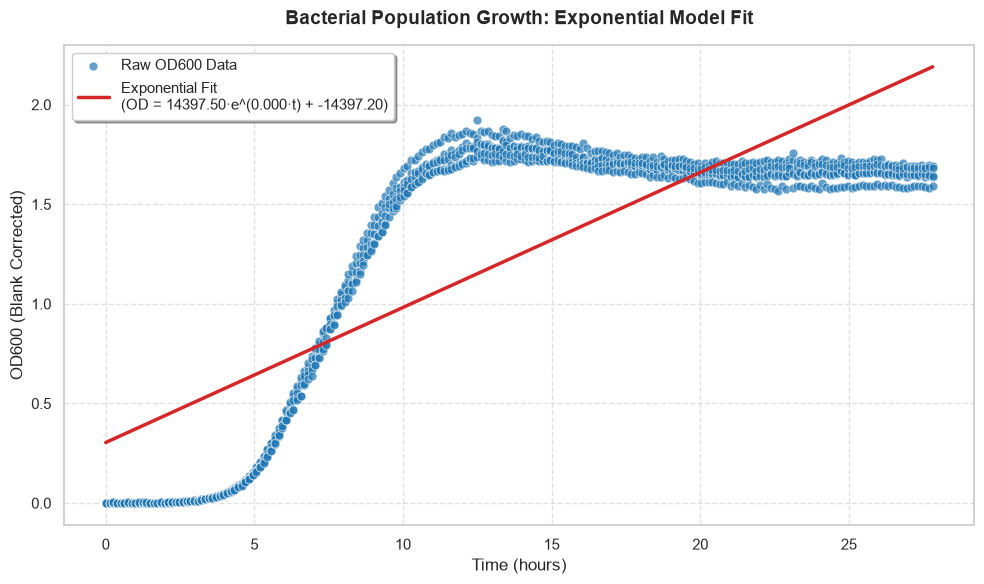

In [17]:
# Generate smooth time points for the fitted curve
# Plot the full time range for the original graph
t_smooth = np.linspace(t_data.min(), t_data.max(), 200)
od_smooth = exponential_growth(t_smooth, a_fit, b_fit, c_fit)

# Create the plot
plt.figure(figsize=(10, 6))

# Plot raw data
sns.scatterplot(
    data=sample_data, 
    x='Time_h', 
    y='OD600', 
    color='#1f77b4', 
    label='Raw OD600 Data', 
    alpha=0.7,
    s=40
)

# Plot fitted exponential curve
plt.plot(
    t_smooth, 
    od_smooth, 
    color='#d62728', 
    linewidth=2.5, 
    label=f'Exponential Fit\n(OD = {a_fit:.2f}·e^({b_fit:.3f}·t) + {c_fit:.2f})'
 )

# Formatting
plt.title('Bacterial Population Growth: Exponential Model Fit', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time (hours)', fontsize=12)
plt.ylabel('OD600 (Blank Corrected)', fontsize=12)
plt.legend(fontsize=11, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)

# Tight layout for clean rendering
plt.tight_layout()
plt.show()

## Talking Point

Around the 10-hour mark, the bacteria enter the **Stationary Phase**. As they run out of food, cell division slows until the rate of new cell growth balances the rate of cell death. The population levels off rather than disappearing immediately.

Growth rate for 0-10 h: 0.2853 h^-1


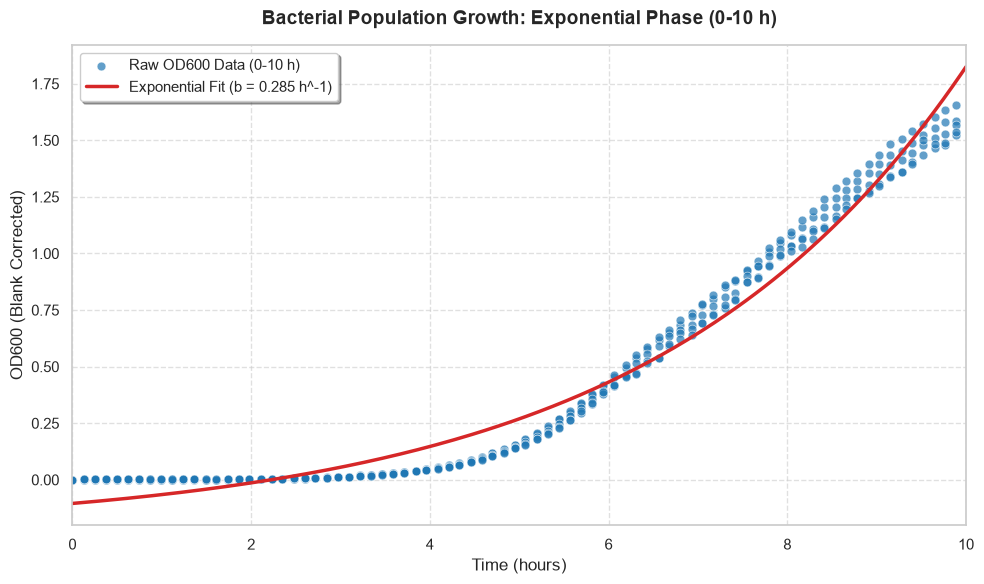

In [19]:
# Fit a separate exponential model to the first 10 hours
early_data = sample_data[sample_data['Time_h'].between(0, 10)].copy()
early_t = early_data['Time_h'].values
early_od = early_data['OD600'].values

early_params, _ = curve_fit(
    exponential_growth,
    early_t,
    early_od,
    p0=[1.0, 0.1, 0.0],
    maxfev=10000
 )
early_a_fit, early_b_fit, early_c_fit = early_params
print(f"Growth rate for 0-10 h: {early_b_fit:.4f} h^-1")

early_t_smooth = np.linspace(0, 10, 200)
early_od_smooth = exponential_growth(
    early_t_smooth, early_a_fit, early_b_fit, early_c_fit
 )

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=early_data,
    x='Time_h',
    y='OD600',
    color='#1f77b4',
    label='Raw OD600 Data (0-10 h)',
    alpha=0.7,
    s=40
 )
plt.plot(
    early_t_smooth,
    early_od_smooth,
    color='#d62728',
    linewidth=2.5,
    label=f'Exponential Fit (b = {early_b_fit:.3f} h^-1)'
 )
plt.title('Bacterial Population Growth: Exponential Phase (0-10 h)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time (hours)', fontsize=12)
plt.ylabel('OD600 (Blank Corrected)', fontsize=12)
plt.xlim(0, 10)
plt.legend(fontsize=11, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()